/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest     0.869   0.786026  0.458015  0.578778  0.713762
1        Decision Tree     0.778   0.441913  0.493639  0.466346  0.670590
0  Logistic Regression     0.817   0.598540  0.208651  0.309434  0.587213


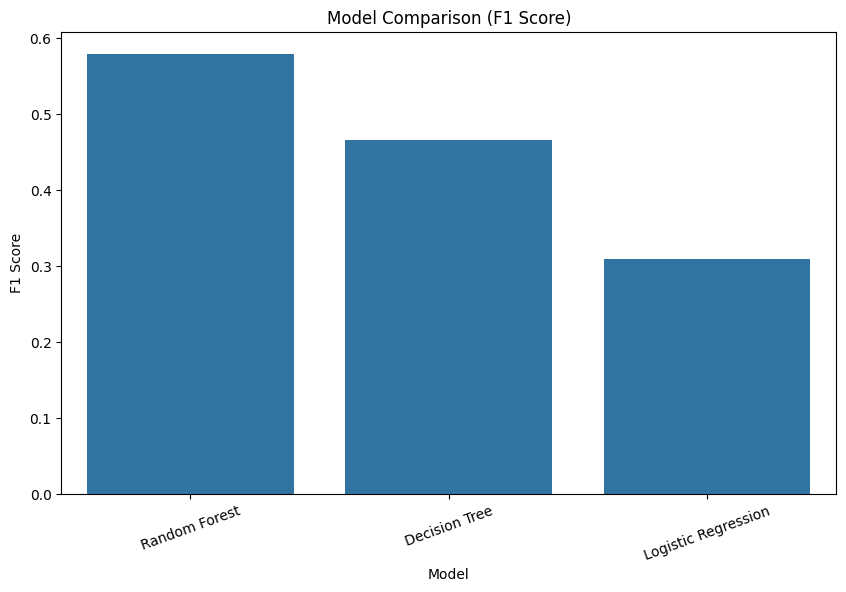

In [2]:
# s1
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,mean_absolute_error,mean_squared_error,classification_report
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# s2
df=pd.read_csv("../data/Churn_Modelling.csv")


# Drop useless columns
df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)

# Encoding
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})
df=pd.get_dummies(df,columns=['Geography'])


# Features & target
X=df.drop('Exited',axis=1)
# X=df[['CreditScore','Gender','Age','Tenure','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary','Geography_France','Geography_Germany','Geography_Spain']]
y=df['Exited']

# Split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.2
)

# Model

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced')
}


# Train & Compare
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, pred)
    })


# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by best model
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison:\n")
print(results_df)


# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="F1 Score", data=results_df)
plt.title("Model Comparison (F1 Score)")
plt.xticks(rotation=20)
plt.show()